In [3]:
import pandas as pd

df= pd.read_csv('/Users/gretawette/Documents/Thesis/03_Framing/outputs/media_framing_final_run_5_4mini_classifications.csv')

In [4]:
from pathlib import Path

root = Path("/Users/gretawette/Documents/Thesis")

topics = pd.read_csv(
    root / "02_TopicModeling/outputs/03_new_topic_assignments.csv",
    usecols=["row_id", "source", "Manual Topic Label", "Manual Cluster Label"],
)

# Normalise source names to match the framing CSV
topics["source"] = topics["source"].replace({
    "RT":             "RT_de",
    "Tichys Einblick": "Tichys_Einblick",
})

df = df.merge(
    topics,
    on=["row_id", "source"],
    how="left",
)

print(f"Rows: {len(df)}")
print(f"Manual Topic Label   — filled: {df['Manual Topic Label'].notna().sum()}  |  missing: {df['Manual Topic Label'].isna().sum()}")
print(f"Manual Cluster Label — filled: {df['Manual Cluster Label'].notna().sum()}  |  missing: {df['Manual Cluster Label'].isna().sum()}")
print()
print(df[["source", "row_id", "category", "Manual Topic Label", "Manual Cluster Label"]].head(10).to_string(index=False))


Rows: 11975
Manual Topic Label   — filled: 11583  |  missing: 392
Manual Cluster Label — filled: 11583  |  missing: 392

     source  row_id                         category            Manual Topic Label          Manual Cluster Label
Antispiegel       1                          NEUTRAL            AfD Party Politics         German Party Politics
Antispiegel       4 DISINFORMATION/FALSCHDARSTELLUNG Ukrainian Military Operations            Russia-Ukraine War
Antispiegel       5             VERSAGEN/INKOMPETENZ         Corruption Journalism Media & Information Ecosystem
Antispiegel       5                       IRRELEVANT         Corruption Journalism Media & Information Ecosystem
Antispiegel       5 DISINFORMATION/FALSCHDARSTELLUNG         Corruption Journalism Media & Information Ecosystem
Antispiegel       5          VERZERRUNG/MANIPULATION         Corruption Journalism Media & Information Ecosystem
Antispiegel       5          VERZERRUNG/MANIPULATION         Corruption Journalism Media

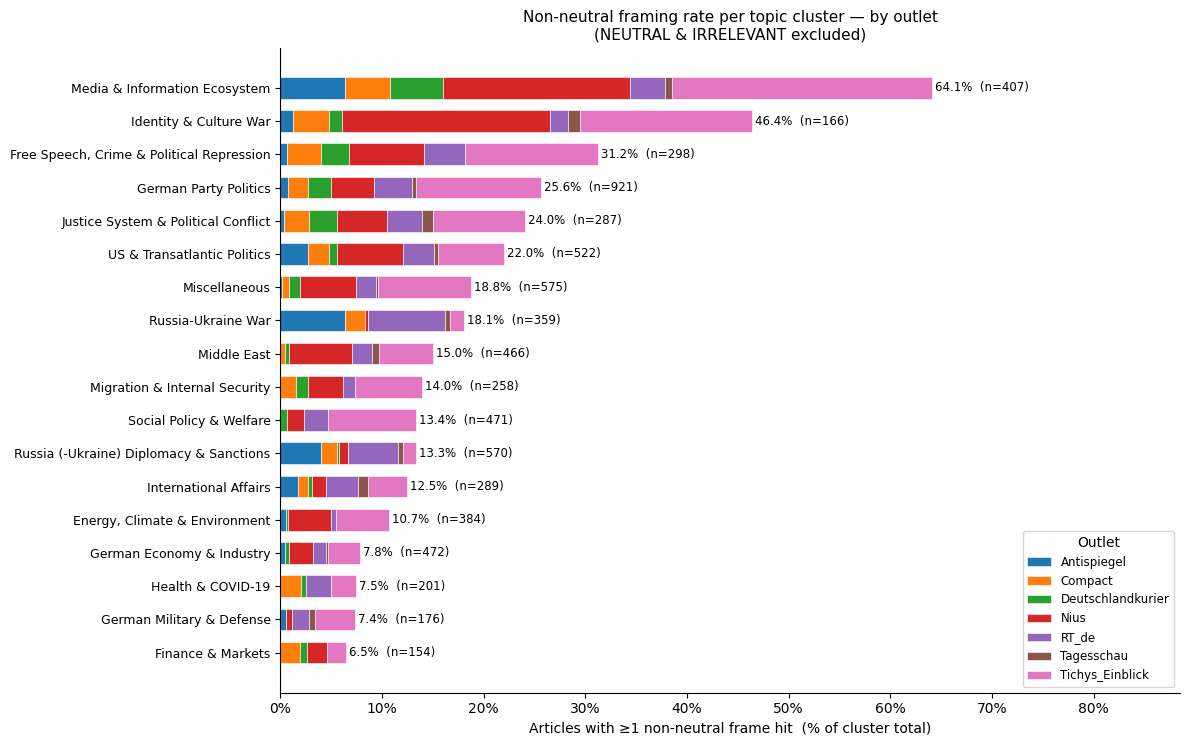

In [70]:
import matplotlib.pyplot as plt
import numpy as np

SKIP_CATS = {"NEUTRAL", "IRRELEVANT"}

# Per (cluster, outlet, article): has ≥1 non-neutral hit?
article_flags = (
    df.dropna(subset=["Manual Cluster Label"])
    .groupby(["row_id", "source", "Manual Cluster Label"])["category"]
    .apply(lambda cats: any(c not in SKIP_CATS for c in cats))
    .reset_index(name="has_frame")
)

# Total articles per cluster (denominator stays the same as before)
total_per_cluster = (
    article_flags.groupby("Manual Cluster Label")["has_frame"].count()
)

# Non-neutral articles per (cluster, outlet)
framed_per_outlet = (
    article_flags[article_flags["has_frame"]]
    .groupby(["Manual Cluster Label", "source"])
    .size()
    .unstack(fill_value=0)
)

# Convert to % of total articles in that cluster
pct_by_outlet = framed_per_outlet.div(total_per_cluster, axis=0) * 100

# Sort clusters by total non-neutral rate ascending (top = highest)
total_pct = pct_by_outlet.sum(axis=1).sort_values(ascending=True)
pct_by_outlet = pct_by_outlet.loc[total_pct.index]

outlets  = pct_by_outlet.columns.tolist()
palette  = plt.get_cmap("tab10")
OUTLET_COLORS = {o: palette(i % 10) for i, o in enumerate(sorted(outlets))}

fig, ax = plt.subplots(figsize=(12, max(6, len(pct_by_outlet) * 0.42)))

lefts = np.zeros(len(pct_by_outlet))
for outlet in sorted(outlets):
    if outlet not in pct_by_outlet.columns:
        continue
    vals = pct_by_outlet[outlet].values
    ax.barh(pct_by_outlet.index, vals, left=lefts,
            color=OUTLET_COLORS[outlet], label=outlet,
            edgecolor="white", linewidth=0.4, height=0.65)
    lefts += vals

# Total % label at bar end
for i, (cluster, total) in enumerate(total_pct.items()):
    n = int(total_per_cluster[cluster])
    ax.text(total + 0.3, i,
            f"{total:.1f}%  (n={n})",
            va="center", ha="left", fontsize=8.5)

ax.set_xlim(0, total_pct.max() * 1.38)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0f}%"))
ax.set_xlabel("Articles with ≥1 non-neutral frame hit  (% of cluster total)")
ax.set_title(
    "Non-neutral framing rate per topic cluster — by outlet\n"
    "(NEUTRAL & IRRELEVANT excluded)",
    fontsize=11
)
ax.legend(loc="lower right", fontsize=8.5, frameon=True, title="Outlet")
ax.spines[["top", "right"]].set_visible(False)
ax.tick_params(axis="y", labelsize=9)

plt.tight_layout()
plt.show()


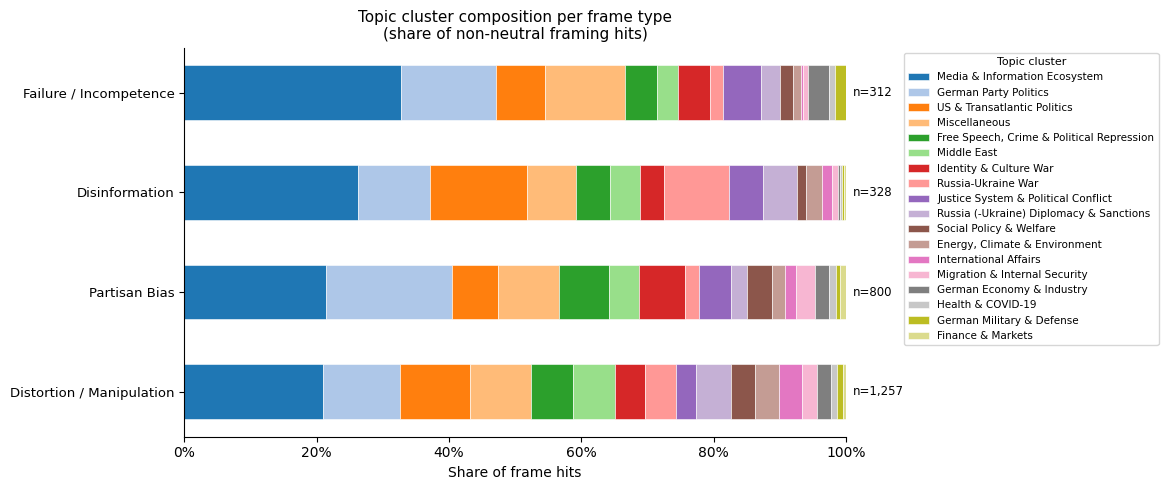

In [71]:
CATEGORY_EN = {
    "VERZERRUNG/MANIPULATION":            "Distortion / Manipulation",
    "POSITIONS-/PARTEILICHKEITS-BIAS":    "Partisan Bias",
    "DISINFORMATION/FALSCHDARSTELLUNG":   "Disinformation",
    "VERSAGEN/INKOMPETENZ":               "Failure / Incompetence",
}
FRAME_ORDER = list(CATEGORY_EN.values())

df_framed = (
    df[df["category"].isin(CATEGORY_EN)]
    .dropna(subset=["Manual Cluster Label"])
    .copy()
)
df_framed["frame_en"] = df_framed["category"].map(CATEGORY_EN)

# Counts: frame × cluster (raw hits)
pivot = (
    df_framed.groupby(["frame_en", "Manual Cluster Label"])
    .size()
    .unstack(fill_value=0)
    .reindex(FRAME_ORDER)
)

# Normalise each row → % share of that frame's hits
props = pivot.div(pivot.sum(axis=1), axis=0) * 100
totals = pivot.sum(axis=1)

# Sort clusters by total hits descending so legend order is meaningful
cluster_order = pivot.sum(axis=0).sort_values(ascending=False).index.tolist()
props = props[cluster_order]

cmap = plt.get_cmap("tab20")
cluster_colors = {c: cmap(i % 20) for i, c in enumerate(cluster_order)}

fig, ax = plt.subplots(figsize=(12, 5))

lefts = np.zeros(len(props))
for cluster in cluster_order:
    vals = props[cluster].values
    ax.barh(props.index, vals, left=lefts,
            color=cluster_colors[cluster], label=cluster,
            edgecolor="white", linewidth=0.4, height=0.55)
    lefts += vals

# Total hit count at bar end
for i, (frame, total) in enumerate(totals.items()):
    ax.text(101, i, f"n={total:,}", va="center", ha="left", fontsize=8.5)

ax.set_xlim(0, 100)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0f}%"))
ax.set_xlabel("Share of frame hits")
ax.set_title(
    "Topic cluster composition per frame type\n"
    "(share of non-neutral framing hits)",
    fontsize=11
)
ax.spines[["top", "right"]].set_visible(False)
ax.tick_params(axis="y", labelsize=9.5)
ax.legend(
    loc="upper left", bbox_to_anchor=(1.08, 1),
    fontsize=7.5, frameon=True, title="Topic cluster",
    title_fontsize=8
)

plt.tight_layout()
plt.show()


In [72]:
import math

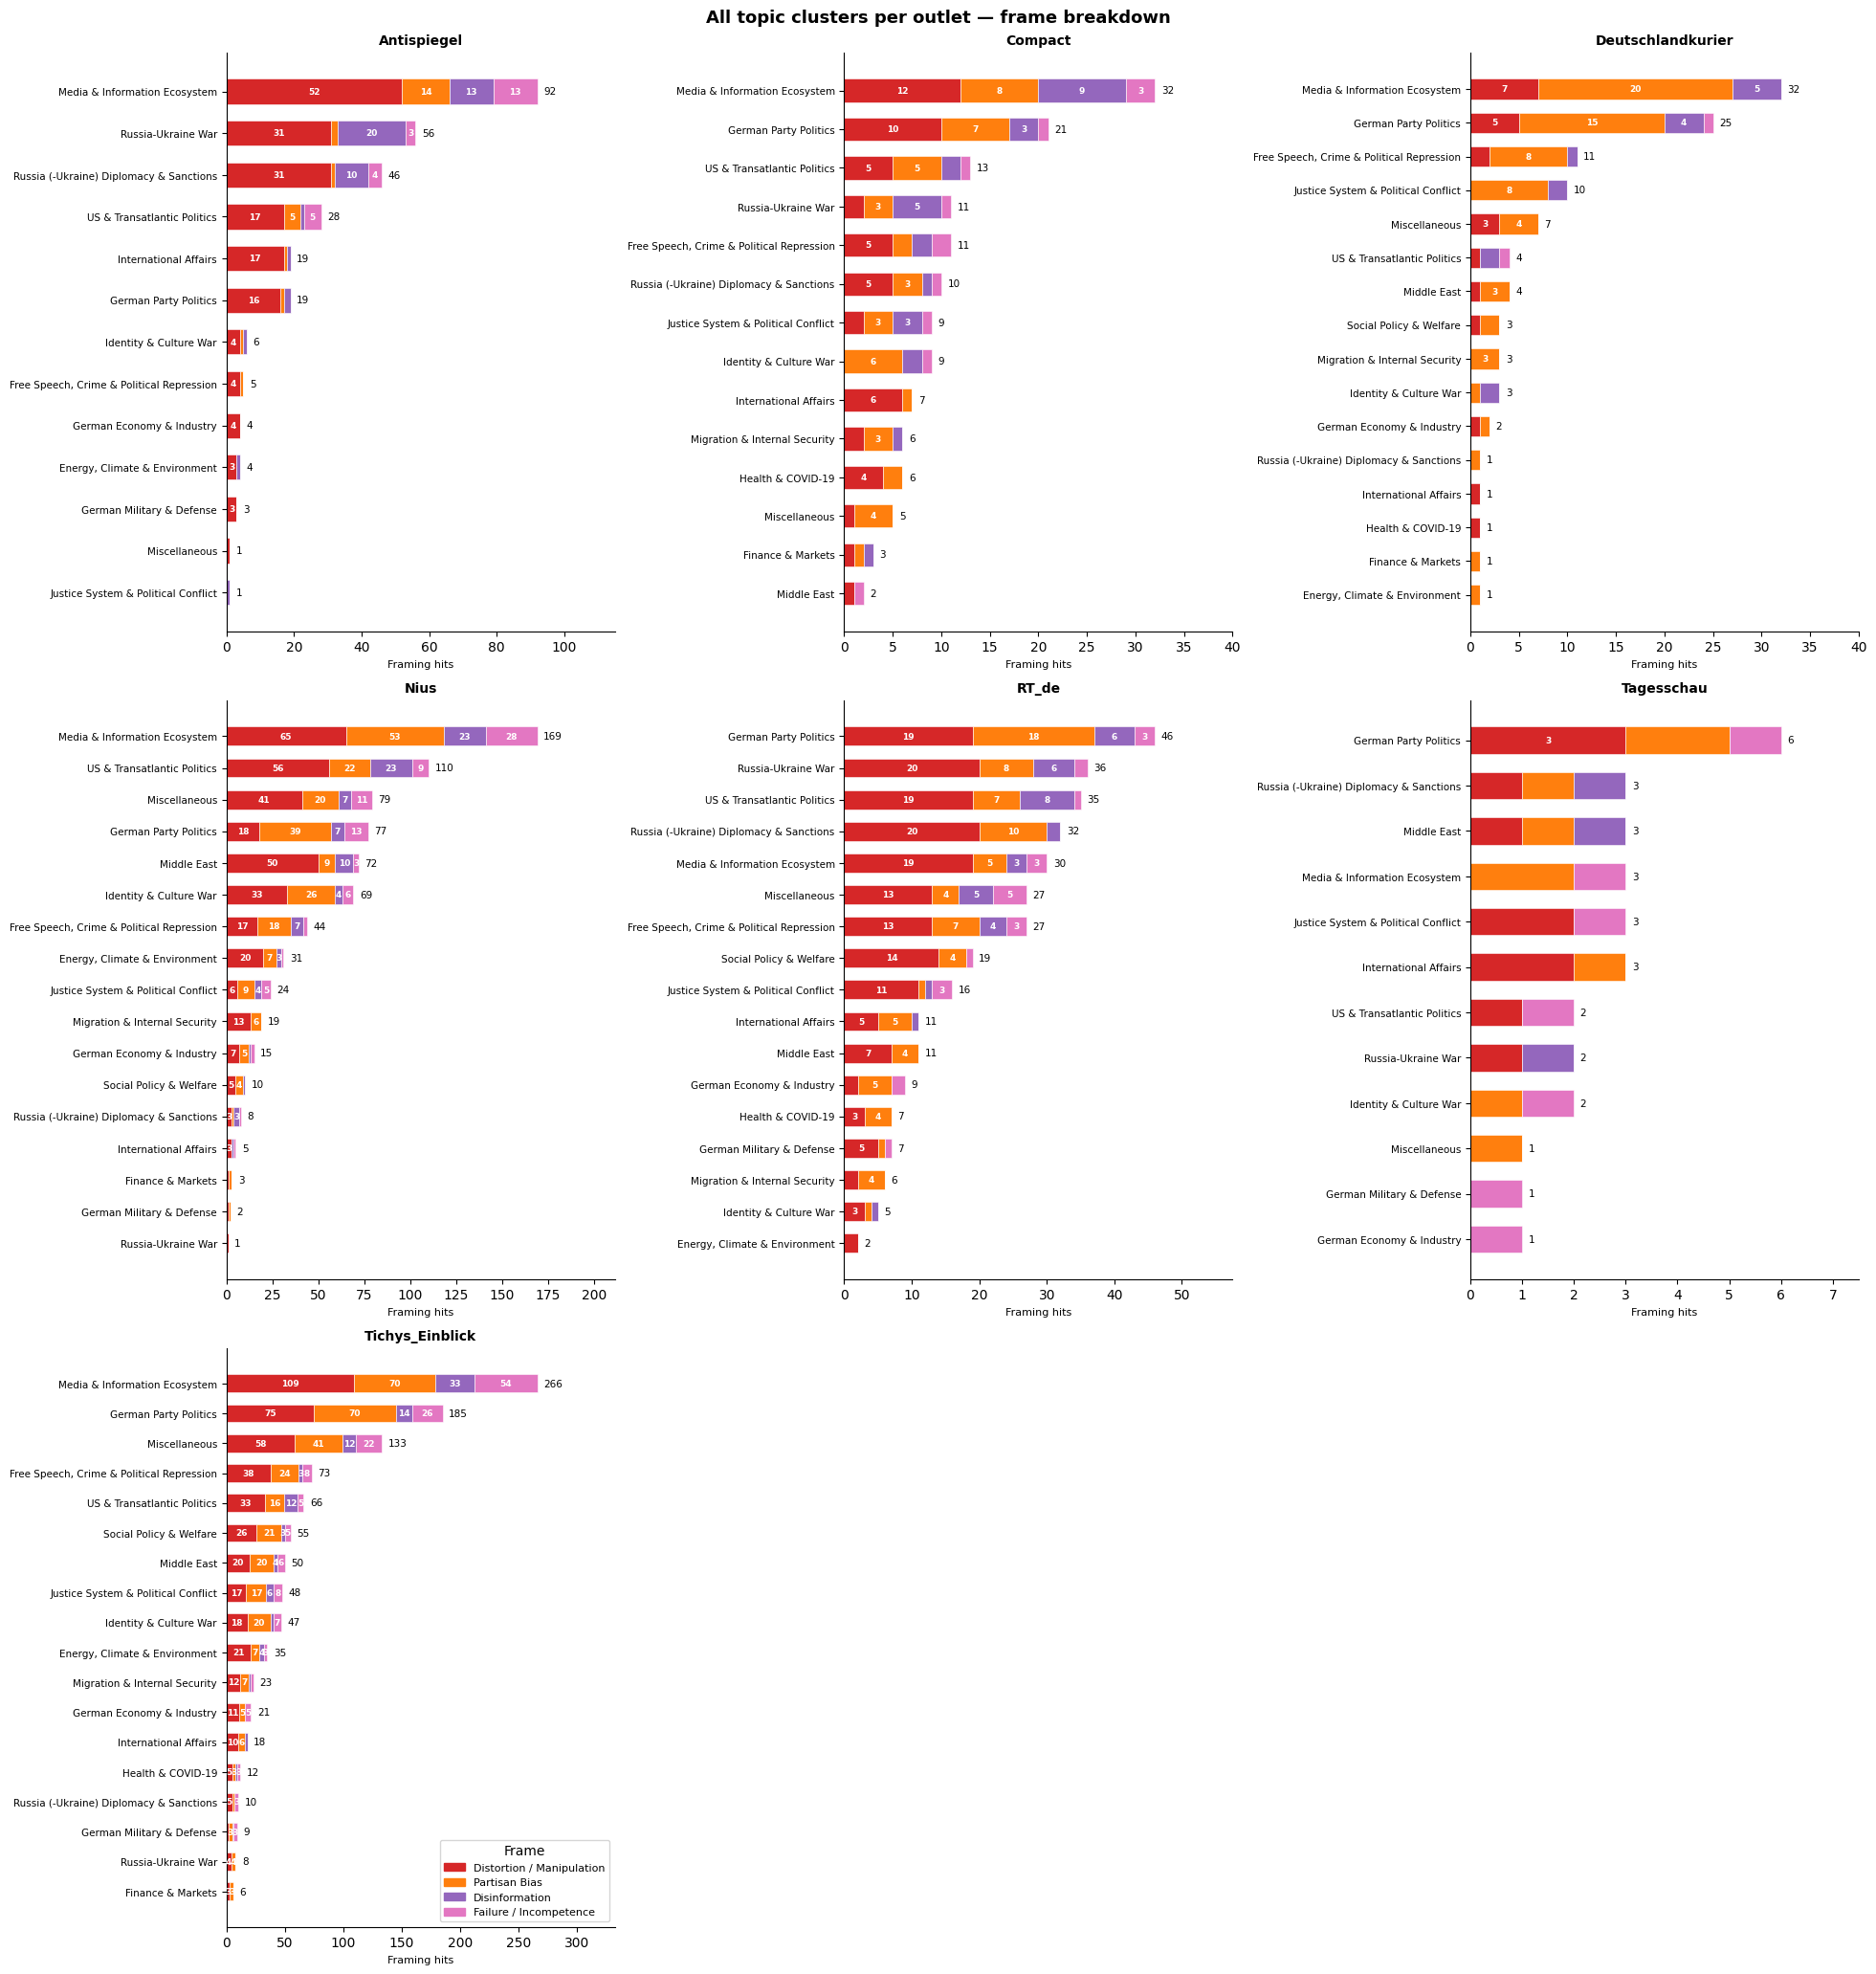

In [73]:
FRAME_COLORS = {
    "Distortion / Manipulation": "#d62728",
    "Partisan Bias":             "#ff7f0e",
    "Disinformation":            "#9467bd",
    "Failure / Incompetence":    "#e377c2",
}

df_framed = (
    df[df["category"].isin(CATEGORY_EN)]
    .dropna(subset=["Manual Cluster Label"])
    .copy()
)
df_framed["frame_en"] = df_framed["category"].map(CATEGORY_EN)

outlets = sorted(df_framed["source"].unique())
ncols   = 3
nrows   = math.ceil(len(outlets) / ncols)

n_clusters = df_framed['Manual Cluster Label'].nunique()
fig, axes = plt.subplots(nrows, ncols,
                         figsize=(ncols * 6.5, nrows * max(4, n_clusters * 0.38)),
                         constrained_layout=True)
axes = axes.flatten()

for ax, outlet in zip(axes, outlets):
    sub = df_framed[df_framed["source"] == outlet]

    pivot = (
        sub.groupby(["Manual Cluster Label", "frame_en"])
        .size()
        .unstack(fill_value=0)
        .reindex(columns=FRAME_ORDER, fill_value=0)
    )
    # All clusters, sorted ascending by total hits (largest at top in barh)
    pivot = pivot.loc[pivot.sum(axis=1).sort_values(ascending=True).index]

    lefts = np.zeros(len(pivot))
    for frame in FRAME_ORDER:
        if frame not in pivot.columns:
            continue
        vals = pivot[frame].values
        ax.barh(pivot.index, vals, left=lefts,
                color=FRAME_COLORS[frame], label=frame,
                edgecolor="white", linewidth=0.4, height=0.6)
        for i, (v, l) in enumerate(zip(vals, lefts)):
            if v >= 3:
                ax.text(l + v / 2, i, str(v), ha="center", va="center",
                        fontsize=6.5, color="white", fontweight="bold")
        lefts += vals

    # Total label
    for i, total in enumerate(pivot.sum(axis=1)):
        ax.text(total + pivot.sum(axis=1).max() * 0.02, i, str(total),
                va="center", fontsize=7.5)

    ax.set_xlim(0, pivot.sum(axis=1).max() * 1.25)
    ax.set_title(outlet, fontweight="bold", fontsize=10)
    ax.set_xlabel("Framing hits", fontsize=8)
    ax.tick_params(axis="y", labelsize=7.5)
    ax.spines[["top", "right"]].set_visible(False)

# Shared legend on last used axis
handles = [plt.Rectangle((0,0),1,1, color=FRAME_COLORS[f], label=f) for f in FRAME_ORDER]
axes[len(outlets)-1].legend(handles=handles, loc="lower right",
                             fontsize=8, frameon=True, title="Frame")

for ax in axes[len(outlets):]:
    ax.set_visible(False)

fig.suptitle(
    "All topic clusters per outlet — frame breakdown",
    fontsize=13, fontweight="bold"
)
plt.show()


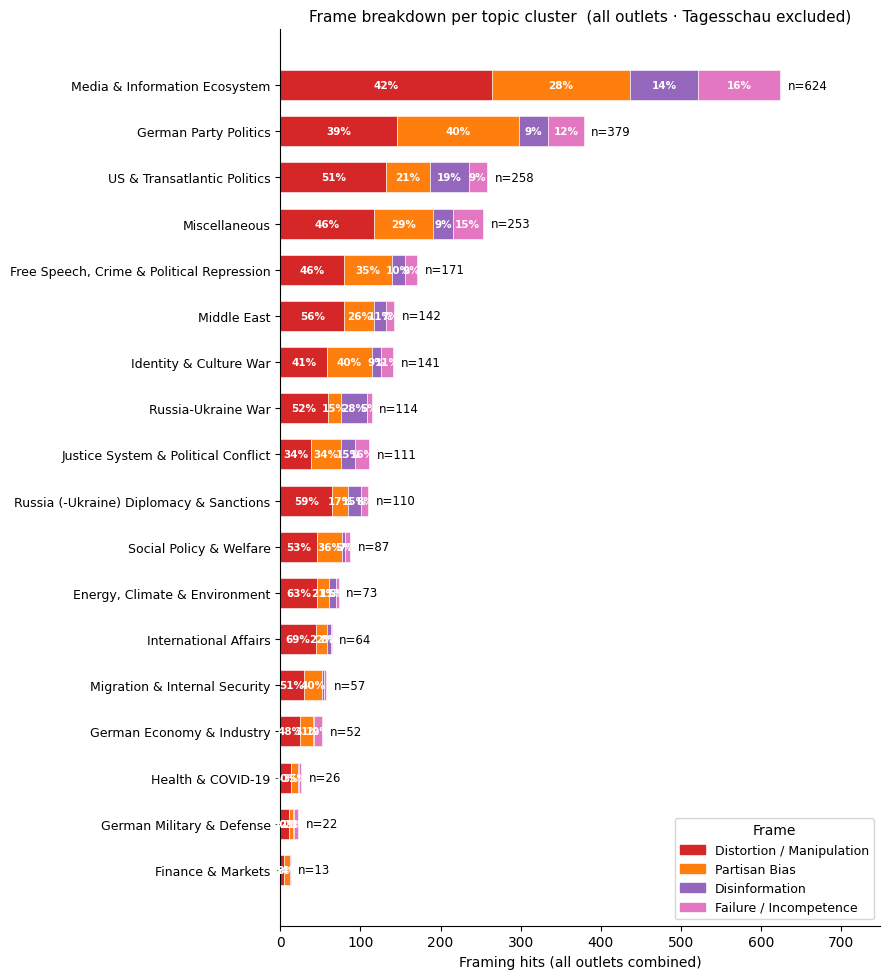

In [74]:
# ── All topic clusters — frame breakdown, bars = raw counts, labels = % ──────
pivot_all = (
    df_framed.groupby(["Manual Cluster Label", "frame_en"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=FRAME_ORDER, fill_value=0)
)

# Sort ascending so the most-framed cluster ends up at top
pivot_all  = pivot_all.loc[pivot_all.sum(axis=1).sort_values(ascending=True).index]
totals_all = pivot_all.sum(axis=1)
pct_all    = pivot_all.div(totals_all, axis=0) * 100   # for label only

fig, ax = plt.subplots(figsize=(9, max(5, len(pivot_all) * 0.55)))

lefts = np.zeros(len(pivot_all))
for frame in FRAME_ORDER:
    if frame not in pivot_all.columns:
        continue
    vals     = pivot_all[frame].values
    pct_vals = pct_all[frame].values
    ax.barh(pivot_all.index, vals, left=lefts,
            color=FRAME_COLORS[frame], label=frame,
            edgecolor="white", linewidth=0.4, height=0.65)
    for i, (v, p, l) in enumerate(zip(vals, pct_vals, lefts)):
        if v >= 4:
            ax.text(l + v / 2, i, f"{p:.0f}%",
                    ha="center", va="center", fontsize=7.5,
                    color="white", fontweight="bold")
    lefts += vals

# Raw n= at bar end
for i, (cluster, total) in enumerate(totals_all.items()):
    ax.text(total + totals_all.max() * 0.015, i, f"n={int(total)}",
            va="center", fontsize=8.5)

ax.set_xlim(0, totals_all.max() * 1.2)
ax.set_xlabel("Framing hits (all outlets combined)", fontsize=10)
ax.set_title("Frame breakdown per topic cluster  (all outlets · Tagesschau excluded)",
             fontsize=11)
ax.tick_params(axis="y", labelsize=9)
ax.spines[["top", "right"]].set_visible(False)

handles = [plt.Rectangle((0, 0), 1, 1, color=FRAME_COLORS[f]) for f in FRAME_ORDER]
ax.legend(handles, FRAME_ORDER, loc="lower right", fontsize=9, frameon=True, title="Frame")

plt.tight_layout()
plt.show()


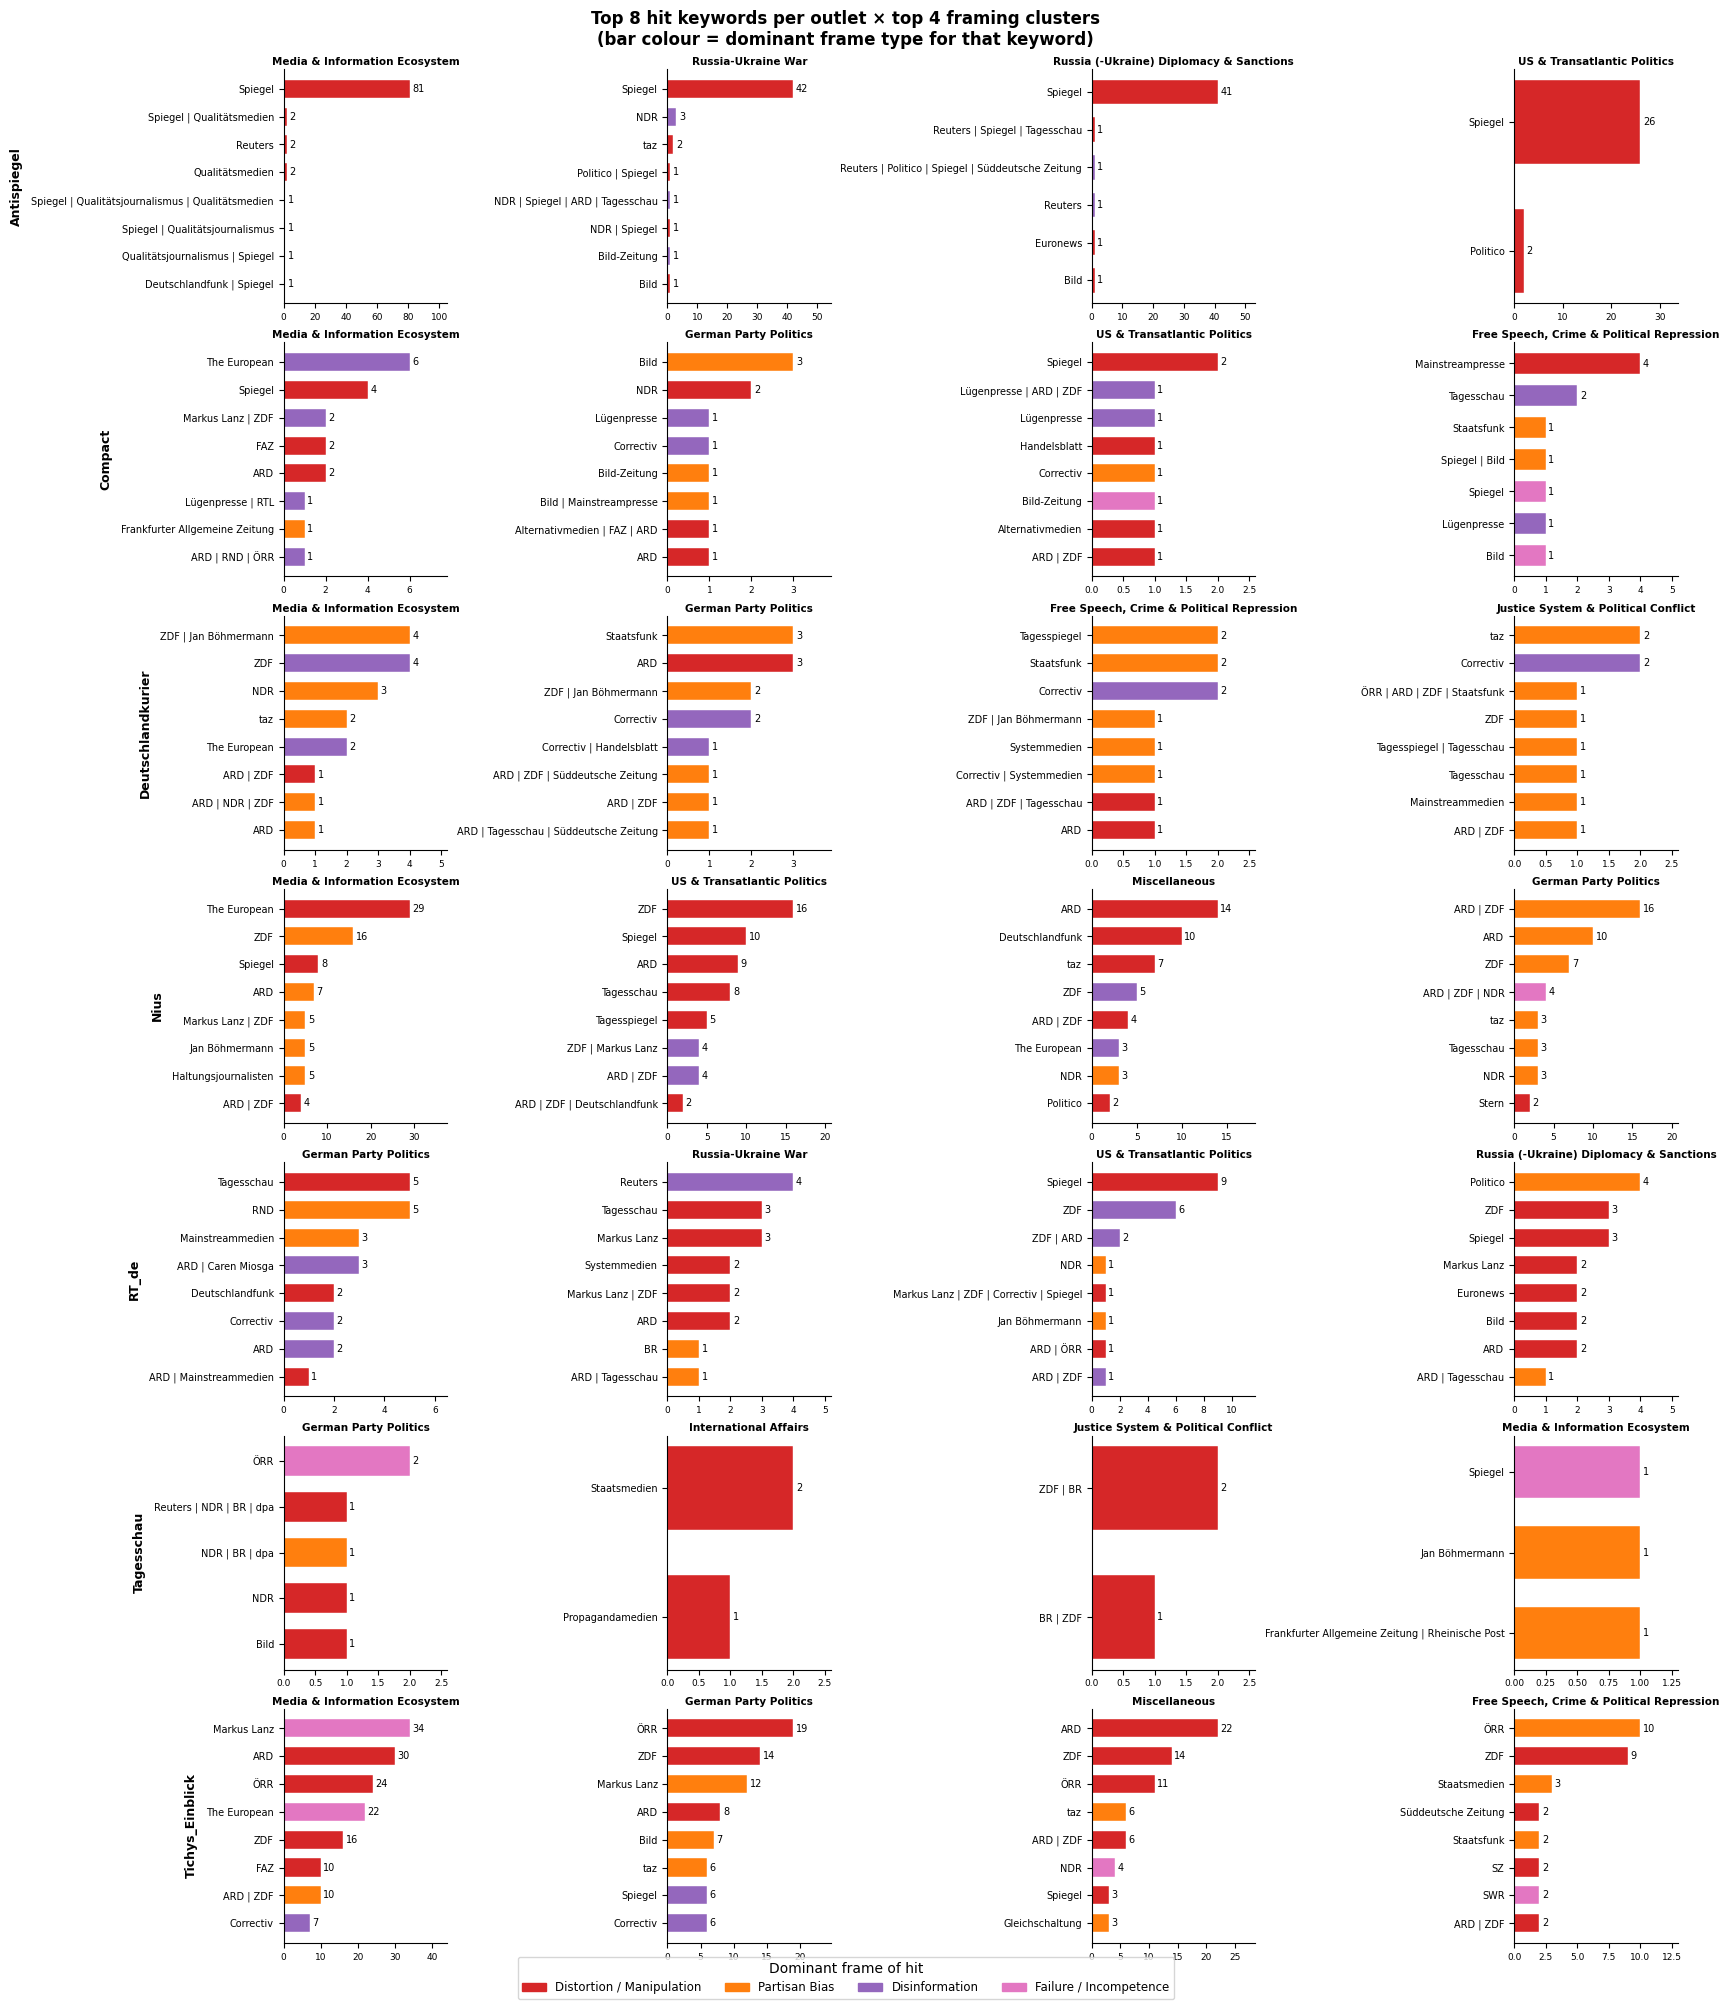

In [75]:
TOP_CLUSTERS = 4   # columns: top clusters per outlet by non-neutral hit count
TOP_HITS     = 8   # rows per mini-panel: top hit_text keywords

SKIP_CATS = {"NEUTRAL", "IRRELEVANT"}

df_framed = (
    df[~df["category"].isin(SKIP_CATS)]
    .dropna(subset=["Manual Cluster Label"])
    .copy()
)
df_framed["frame_en"] = df_framed["category"].map(CATEGORY_EN)

outlets = sorted(df_framed["source"].unique())

fig, axes = plt.subplots(
    len(outlets), TOP_CLUSTERS,
    figsize=(TOP_CLUSTERS * 4.2, len(outlets) * 2.8),
    constrained_layout=True,
)

for row_idx, outlet in enumerate(outlets):
    sub_outlet = df_framed[df_framed["source"] == outlet]

    # Top clusters for this outlet
    top_clusters = (
        sub_outlet.groupby("Manual Cluster Label").size()
        .nlargest(TOP_CLUSTERS).index.tolist()
    )
    # Pad with None if fewer clusters than columns
    top_clusters += [None] * (TOP_CLUSTERS - len(top_clusters))

    for col_idx, cluster in enumerate(top_clusters):
        ax = axes[row_idx][col_idx] if len(outlets) > 1 else axes[col_idx]

        if cluster is None:
            ax.set_visible(False)
            continue

        sub = sub_outlet[sub_outlet["Manual Cluster Label"] == cluster]
        top = (
            sub.groupby("hit_text").size()
            .nlargest(TOP_HITS)
            .sort_values()          # ascending → largest bar at top
        )

        colors = [FRAME_COLORS.get(
            sub[sub["hit_text"] == ht]["frame_en"].mode().iloc[0]
            if not sub[sub["hit_text"] == ht].empty else "", "#999"
        ) for ht in top.index]

        ax.barh(top.index, top.values, color=colors,
                edgecolor="white", linewidth=0.3, height=0.65)

        for i, v in enumerate(top.values):
            ax.text(v + top.values.max() * 0.02, i, str(v),
                    va="center", fontsize=7)

        ax.set_xlim(0, top.values.max() * 1.3)
        ax.set_title(cluster, fontsize=7.5, fontweight="bold", pad=3)
        ax.tick_params(axis="y", labelsize=7)
        ax.tick_params(axis="x", labelsize=6.5)
        ax.spines[["top", "right"]].set_visible(False)

        # Outlet label on leftmost column only
        if col_idx == 0:
            ax.set_ylabel(outlet, fontsize=9, fontweight="bold", labelpad=6)

# Legend for dominant frame colour
legend_handles = [
    plt.Rectangle((0,0),1,1, color=c, label=f)
    for f, c in FRAME_COLORS.items()
]
fig.legend(handles=legend_handles, loc="lower center",
           ncol=len(FRAME_COLORS), fontsize=8.5,
           frameon=True, title="Dominant frame of hit",
           bbox_to_anchor=(0.5, -0.02))

fig.suptitle(
    f"Top {TOP_HITS} hit keywords per outlet × top {TOP_CLUSTERS} framing clusters\n"
    "(bar colour = dominant frame type for that keyword)",
    fontsize=12, fontweight="bold"
)
plt.show()


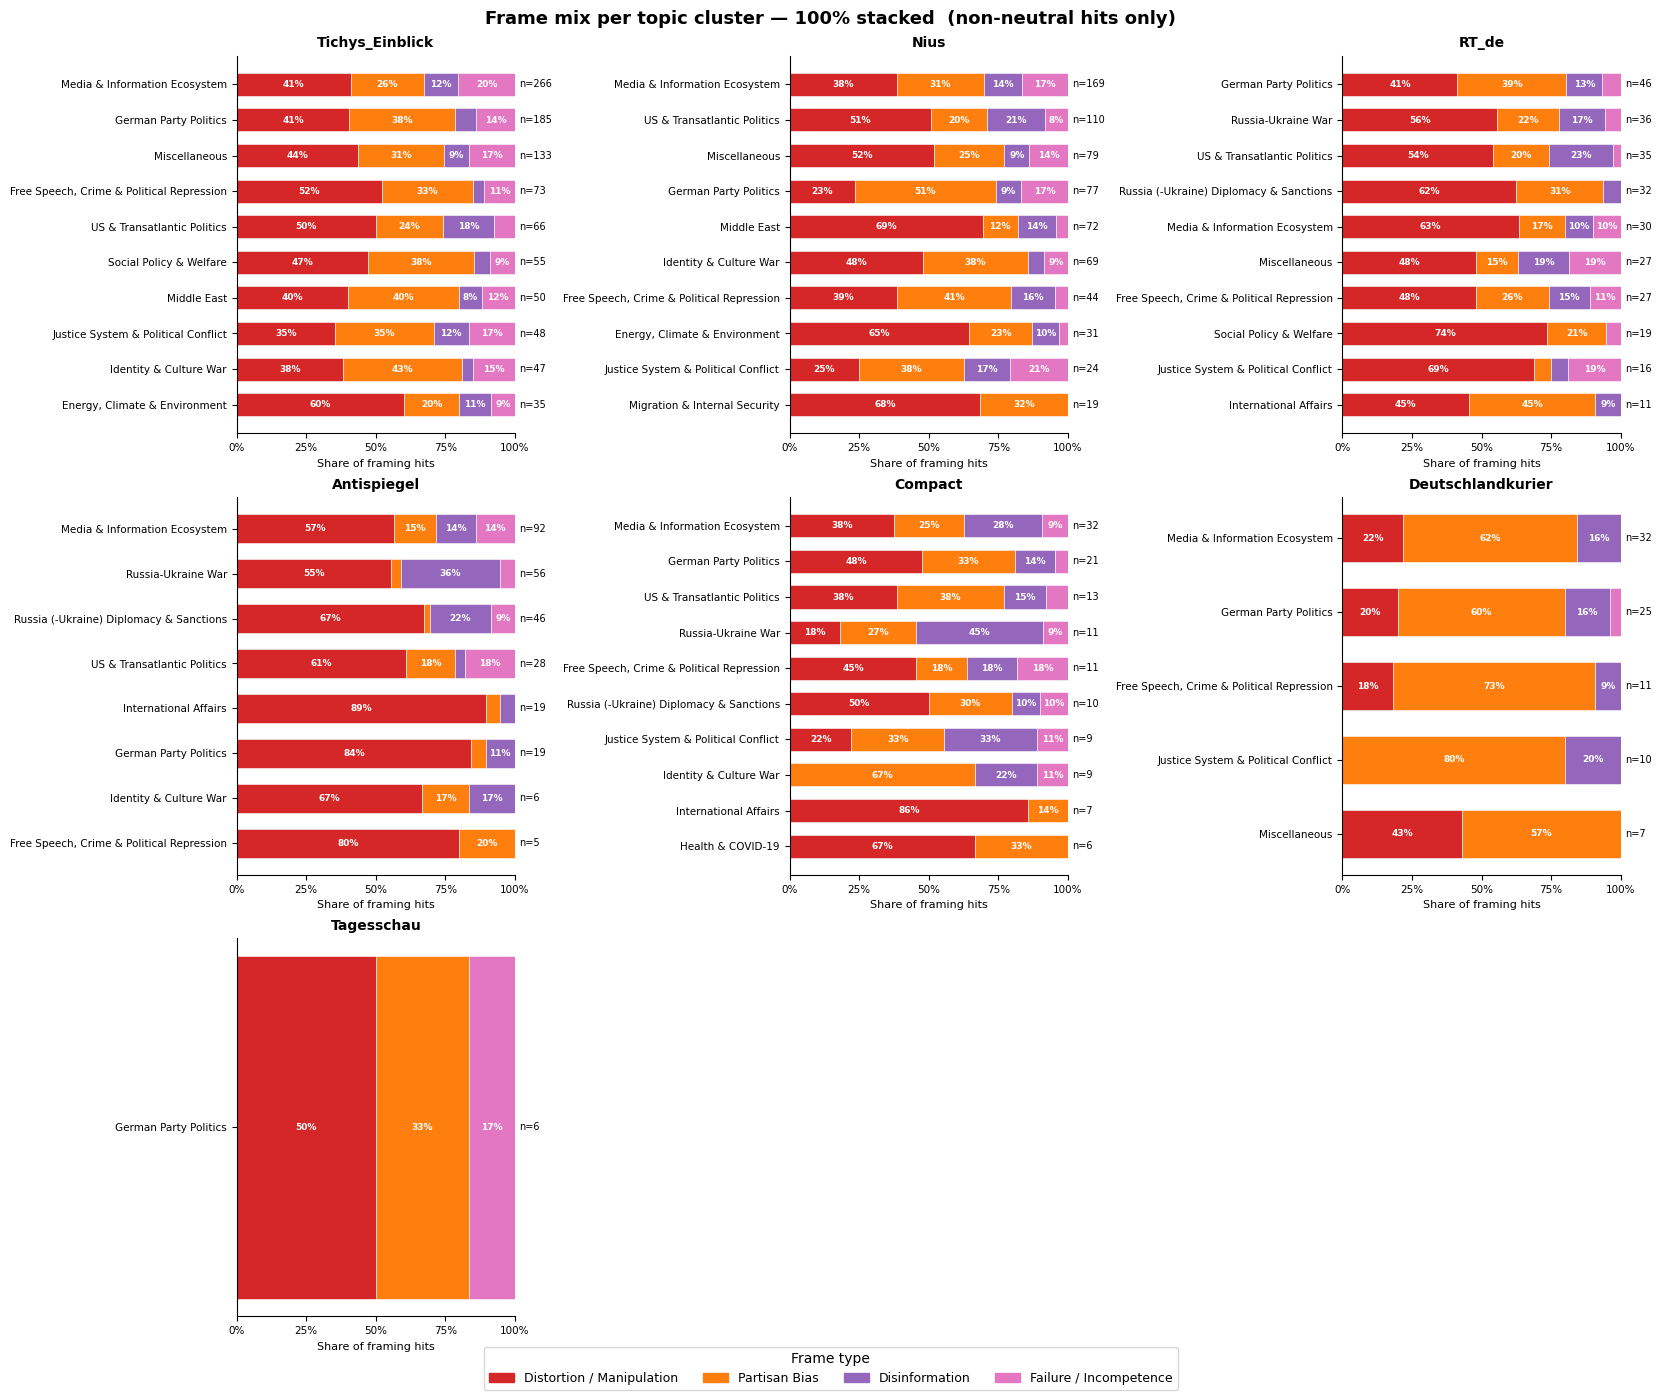

In [76]:
# ── Small multiples: 100% stacked bar — frame mix per topic cluster per outlet
# Each row = one topic cluster, each bar = 100%, segments = frame share.
# Normalised PER ROW so you can compare frame composition across outlets.

TOP_N_CLUSTERS = 10   # clusters shown per outlet (by total non-neutral hit count)
MIN_N          = 5    # hide rows with fewer than this many hits

df_framed = (
    df[df["category"].isin(CATEGORY_EN)]
    .dropna(subset=["Manual Cluster Label"])
    .copy()
)
df_framed["frame_en"] = df_framed["category"].map(CATEGORY_EN)

outlets = (
    df_framed.groupby("source").size()
    .sort_values(ascending=False)
    .index.tolist()
)
ncols   = 3
nrows   = math.ceil(len(outlets) / ncols)

fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(ncols * 5.5, nrows * 4.5),
    constrained_layout=True,
)
axes = axes.flatten()

for ax, outlet in zip(axes, outlets):
    sub = df_framed[df_framed["source"] == outlet]

    # Raw counts: cluster × frame
    raw = (
        sub.groupby(["Manual Cluster Label", "frame_en"])
        .size()
        .unstack(fill_value=0)
        .reindex(columns=FRAME_ORDER, fill_value=0)
    )

    # Keep top N clusters by total hits; drop rows below MIN_N
    raw = raw[raw.sum(axis=1) >= MIN_N]
    if raw.empty:
        ax.set_visible(False)
        continue
    top_clusters = raw.sum(axis=1).nlargest(TOP_N_CLUSTERS).index
    raw = raw.loc[top_clusters]

    # Normalise each row to 100%
    totals = raw.sum(axis=1)
    pct    = raw.div(totals, axis=0) * 100

    # Sort by total hit count ascending so most-framed cluster is at the top
    pct = pct.loc[totals.sort_values(ascending=True).index]
    totals = totals.reindex(pct.index)

    lefts = np.zeros(len(pct))
    for frame in FRAME_ORDER:
        vals = pct[frame].values
        ax.barh(range(len(pct)), vals, left=lefts,
                color=FRAME_COLORS[frame], label=frame,
                edgecolor="white", linewidth=0.4, height=0.65)
        for i, (v, l) in enumerate(zip(vals, lefts)):
            if v >= 8:
                ax.text(l + v / 2, i, f"{v:.0f}%",
                        ha="center", va="center",
                        fontsize=6.5, color="white", fontweight="bold")
        lefts += vals

    # n= annotation at bar end
    for i, (cluster, n) in enumerate(totals.items()):
        ax.text(101.5, i, f"n={n}", va="center", fontsize=7)

    ax.set_xlim(0, 100)
    ax.set_xticks([0, 25, 50, 75, 100])
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0f}%"))
    ax.set_yticks(range(len(pct)))
    ax.set_yticklabels(pct.index, fontsize=7.5)
    ax.set_title(outlet, fontweight="bold", fontsize=10)
    ax.set_xlabel("Share of framing hits", fontsize=8)
    ax.spines[["top", "right"]].set_visible(False)
    ax.tick_params(axis="x", labelsize=7.5)

# Shared legend
handles = [plt.Rectangle((0,0),1,1, color=FRAME_COLORS[f], label=f)
           for f in FRAME_ORDER]
fig.legend(handles=handles, loc="lower center",
           ncol=len(FRAME_ORDER), fontsize=9,
           frameon=True, title="Frame type",
           bbox_to_anchor=(0.5, -0.03))

for ax in axes[len(outlets):]:
    ax.set_visible(False)

fig.suptitle(
    "Frame mix per topic cluster — 100% stacked  (non-neutral hits only)",
    fontsize=13, fontweight="bold"
)
plt.show()


In [77]:
# Split combined hit_text entries like "ARD | ZDF | Spiegel" into one row each
df = (
    df.assign(hit_text=df["hit_text"].str.split(r"\s*\|\s*"))
    .explode("hit_text")
    .assign(hit_text=lambda d: d["hit_text"].str.strip())
)

print(f"Rows after splitting combined hits: {len(df)}")
print(df["hit_text"].value_counts().head(15))

Rows after splitting combined hits: 14702
hit_text
Deutschlandfunk    1316
ZDF                1287
Spiegel            1199
ARD                 973
Reuters             750
NDR                 617
SWR                 496
dpa                 489
WDR                 482
Markus Lanz         457
Politico            418
Tagesschau          413
MDR                 371
FAZ                 345
ÖRR                 325
Name: count, dtype: int64


In [78]:
# ── Diagnostics: Deutschlandkurier hit counts at each pipeline stage ──────────
OUTLET = "Deutschlandkurier"
SKIP   = {"NEUTRAL", "IRRELEVANT"}

sub = df[df["source"] == OUTLET].copy()

print("=== After load + merge + hit_text split ===")
print(f"Total rows (all categories):            {len(sub)}")

non_neutral = sub[~sub["category"].isin(SKIP)]
print(f"Non-neutral/irrelevant hits (raw rows): {len(non_neutral)}")

no_topic = non_neutral[non_neutral["Manual Cluster Label"].isna()]
has_topic = non_neutral[non_neutral["Manual Cluster Label"].notna()]
print(f"  of which — no topic assignment (NaN): {len(no_topic)}")
print(f"  of which — has topic assignment:      {len(has_topic)}")
print()

print("=== Article-level (dedup by row_id) ===")
# Dedup before split: one article can expand to multiple hit rows after explode
nn_dedup = non_neutral.drop_duplicates(subset=["row_id"])
print(f"Unique articles (row_id) non-neutral:   {len(nn_dedup)}")
nn_topic_dedup = has_topic.drop_duplicates(subset=["row_id"])
print(f"Unique articles with topic assignment:  {len(nn_topic_dedup)}")
print()

print("=== Source of difference ===")
hit_diff = len(non_neutral) - len(has_topic)
art_diff = len(nn_dedup) - len(nn_topic_dedup)
print(f"Hit-level  gap (non-neutral − has_topic):             {hit_diff}")
print(f"Article-level gap (unique non-neutral − unique+topic): {art_diff}")
print()

# Check whether hit_text split inflated counts
orig_ids = sub["row_id"].value_counts()
multi = orig_ids[orig_ids > 1]
print(f"row_ids with >1 hit row after split: {len(multi)}")
print(f"Extra rows from splitting:           {multi.sum() - len(multi)}")
print()

# Category breakdown of the NaN-topic non-neutral rows
print("Category breakdown of no-topic non-neutral rows:")
print(no_topic["category"].value_counts().to_string())
print()
print("Sample no-topic rows:")
print(no_topic[["row_id", "category", "hit_text", "Manual Cluster Label"]].head(10).to_string(index=False))


=== After load + merge + hit_text split ===
Total rows (all categories):            500
Non-neutral/irrelevant hits (raw rows): 202
  of which — no topic assignment (NaN): 25
  of which — has topic assignment:      177

=== Article-level (dedup by row_id) ===
Unique articles (row_id) non-neutral:   92
Unique articles with topic assignment:  85

=== Source of difference ===
Hit-level  gap (non-neutral − has_topic):             25
Article-level gap (unique non-neutral − unique+topic): 7

row_ids with >1 hit row after split: 113
Extra rows from splitting:           206

Category breakdown of no-topic non-neutral rows:
category
POSITIONS-/PARTEILICHKEITS-BIAS     16
VERZERRUNG/MANIPULATION              6
VERSAGEN/INKOMPETENZ                 2
DISINFORMATION/FALSCHDARSTELLUNG     1

Sample no-topic rows:
 row_id                        category            hit_text Manual Cluster Label
  13033 POSITIONS-/PARTEILICHKEITS-BIAS Süddeutsche Zeitung                  NaN
  13033 POSITIONS-/PARTEILI

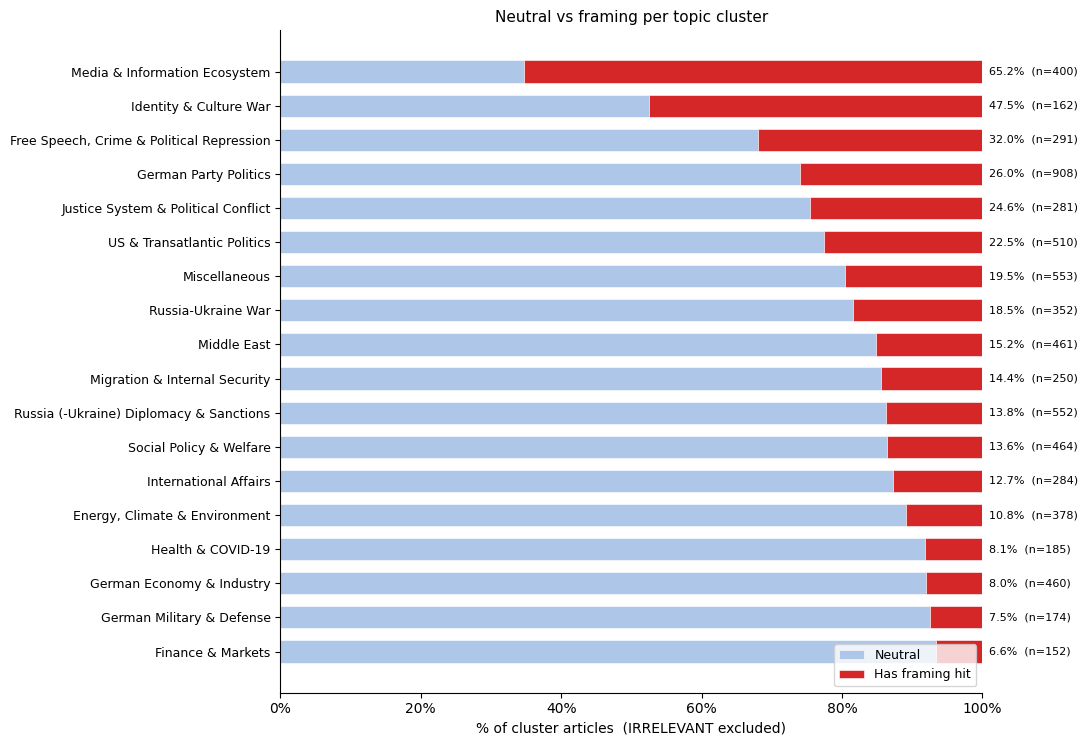

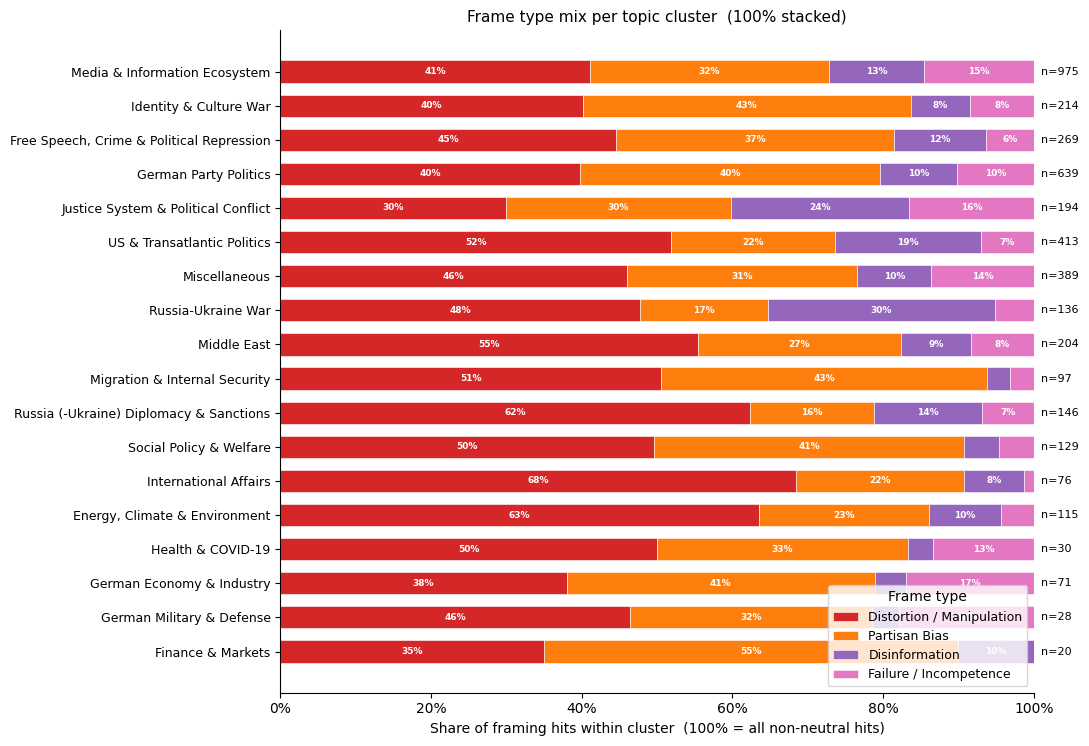

In [79]:
# ── Two companion charts to the outlet-coloured framing rate bar chart ────────
#
# Chart A: per cluster — % neutral vs % with framing hits  (IRRELEVANT excluded)
# Chart B: per cluster — framing hits broken down by frame type
#          bar length = same total non-neutral rate; colour = frame type

SKIP_IRRELEVANT = {"IRRELEVANT"}

# ── Shared base: articles per cluster, IRRELEVANT excluded ────────────────────
base = df[~df["category"].isin(SKIP_IRRELEVANT)].dropna(subset=["Manual Cluster Label"])

# Article-level flag: has ≥1 non-neutral hit?
art_flags = (
    base.groupby(["row_id", "source", "Manual Cluster Label"])["category"]
    .apply(lambda cats: any(c not in {"NEUTRAL", "IRRELEVANT"} for c in cats))
    .reset_index(name="has_frame")
)
total_per_cluster = art_flags.groupby("Manual Cluster Label")["has_frame"].count()
framed_count      = art_flags[art_flags["has_frame"]].groupby("Manual Cluster Label").size()
framed_pct        = (framed_count / total_per_cluster * 100).fillna(0)
neutral_pct       = 100 - framed_pct

# Sort clusters: highest framing rate at top
order = framed_pct.sort_values(ascending=True).index

# ── Chart A ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, max(5, len(order) * 0.42)))

ax.barh(order, neutral_pct[order],               color="#aec7e8", label="Neutral",  height=0.65, edgecolor="white", lw=0.4)
ax.barh(order, framed_pct[order],  left=neutral_pct[order],
        color="#d62728", label="Has framing hit", height=0.65, edgecolor="white", lw=0.4)

for i, cluster in enumerate(order):
    fp = framed_pct[cluster]
    n  = int(total_per_cluster[cluster])
    ax.text(101, i, f"{fp:.1f}%  (n={n})", va="center", ha="left", fontsize=8)

ax.set_xlim(0, 100)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0f}%"))
ax.set_xlabel("% of cluster articles  (IRRELEVANT excluded)")
ax.set_title("Neutral vs framing per topic cluster", fontsize=11)
ax.legend(loc="lower right", fontsize=9, frameon=True)
ax.tick_params(axis="y", labelsize=9)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

# ── Chart B: frame-type breakdown — 100% stacked per cluster ─────────────────
# Normalised to 100% of framing hits within each cluster
df_framing = base[base["category"].isin(CATEGORY_EN)].copy()
df_framing["frame_en"] = df_framing["category"].map(CATEGORY_EN)

hit_counts = (
    df_framing.groupby(["Manual Cluster Label", "frame_en"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=FRAME_ORDER, fill_value=0)
)
# Normalise each row to 100% of that cluster's framing hits
hit_totals = hit_counts.sum(axis=1)
frame_pct  = hit_counts.div(hit_totals, axis=0).fillna(0) * 100
frame_pct  = frame_pct.loc[order]   # same cluster order as Chart A
hit_totals = hit_totals.reindex(order)

fig, ax = plt.subplots(figsize=(11, max(5, len(order) * 0.42)))

lefts = np.zeros(len(frame_pct))
for frame in FRAME_ORDER:
    vals = frame_pct[frame].values
    ax.barh(frame_pct.index, vals, left=lefts,
            color=FRAME_COLORS[frame], label=frame,
            height=0.65, edgecolor="white", lw=0.4)
    for i, (v, l) in enumerate(zip(vals, lefts)):
        if v >= 6:
            ax.text(l + v / 2, i, f"{v:.0f}%",
                    ha="center", va="center", fontsize=6.5,
                    color="white", fontweight="bold")
    lefts += vals

# Raw framing hit count at bar end
for i, (cluster, n_hits) in enumerate(hit_totals.items()):
    ax.text(101, i, f"n={int(n_hits)}", va="center", ha="left", fontsize=8)

ax.set_xlim(0, 100)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0f}%"))
ax.set_xlabel("Share of framing hits within cluster  (100% = all non-neutral hits)")
ax.set_title("Frame type mix per topic cluster  (100% stacked)", fontsize=11)
ax.legend(loc="lower right", fontsize=9, frameon=True, title="Frame type")
ax.tick_params(axis="y", labelsize=9)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()
